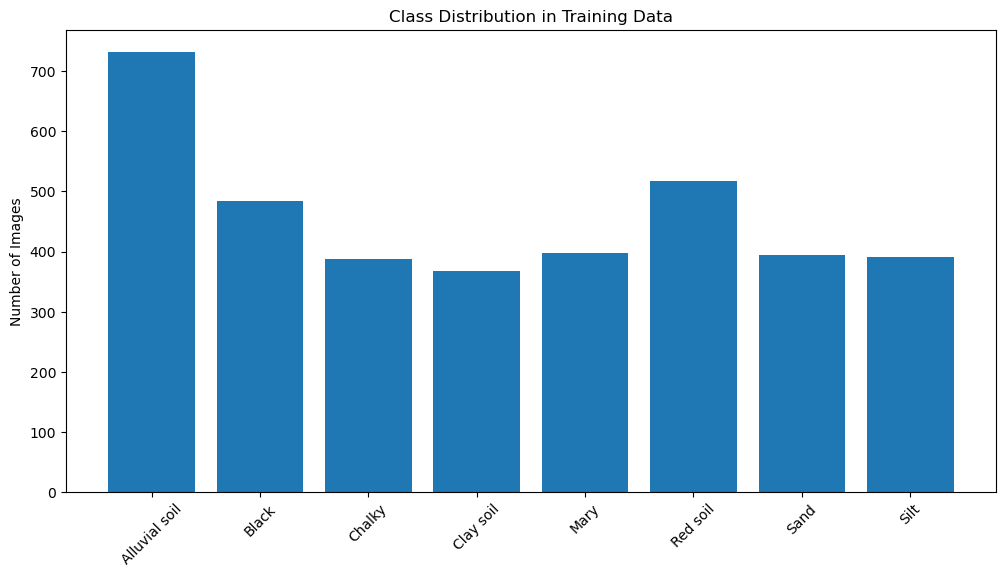

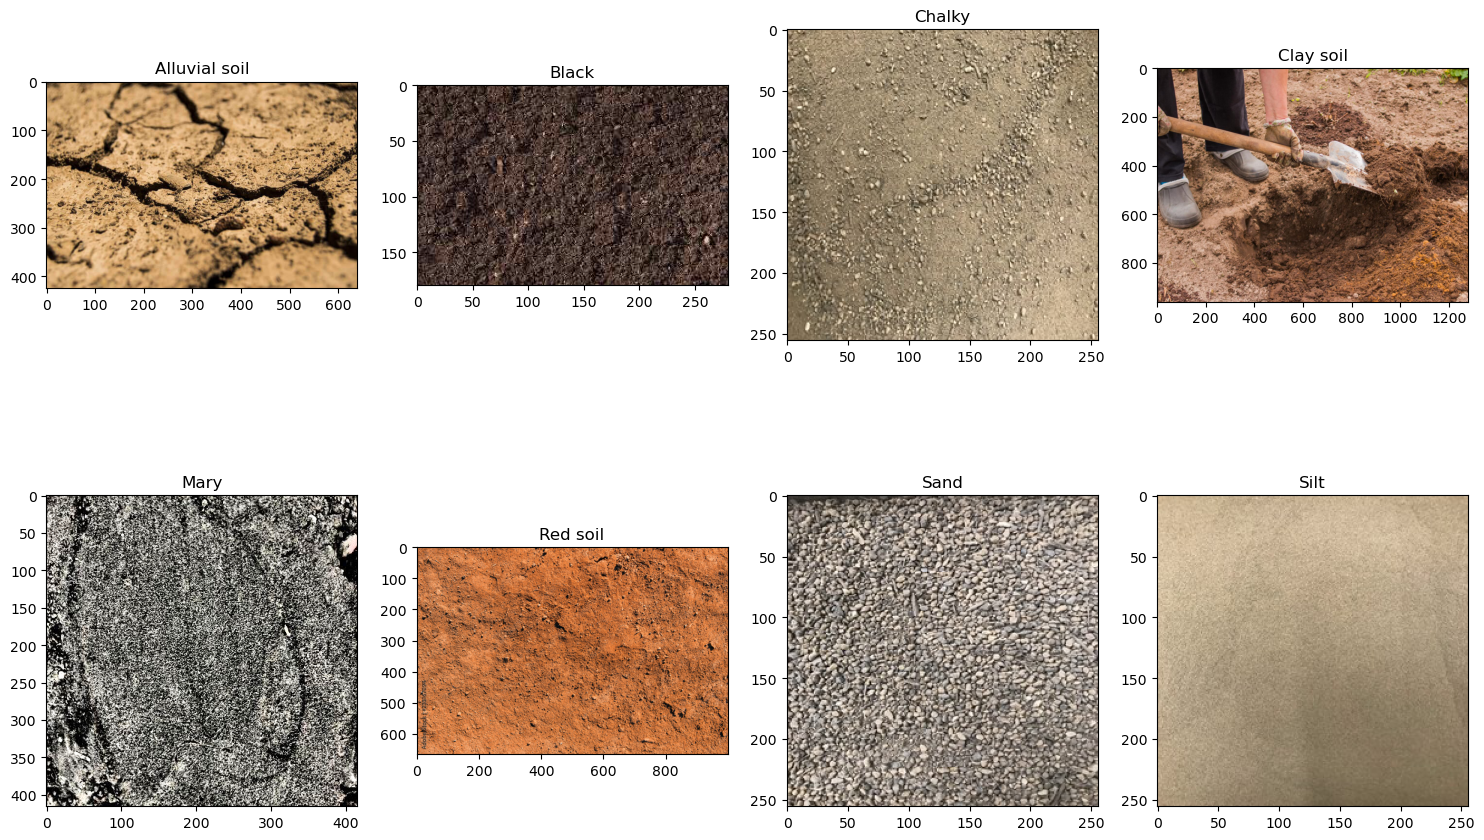

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# ==================== 1. Data Analysis ====================
# Set paths
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Analyze class distribution
class_names = sorted(os.listdir(train_dir))
class_counts = [len(os.listdir(os.path.join(train_dir, name))) for name in class_names]

plt.figure(figsize=(12,6))
plt.bar(class_names, class_counts)
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Images")
plt.show()

# Display sample images
plt.figure(figsize=(15,10))
for i, class_name in enumerate(class_names[:8]):
    img_path = os.path.join(train_dir, class_name, os.listdir(os.path.join(train_dir, class_name))[0])
    img = Image.open(img_path)
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(class_name)
plt.tight_layout()
plt.show()

# Experiment 1

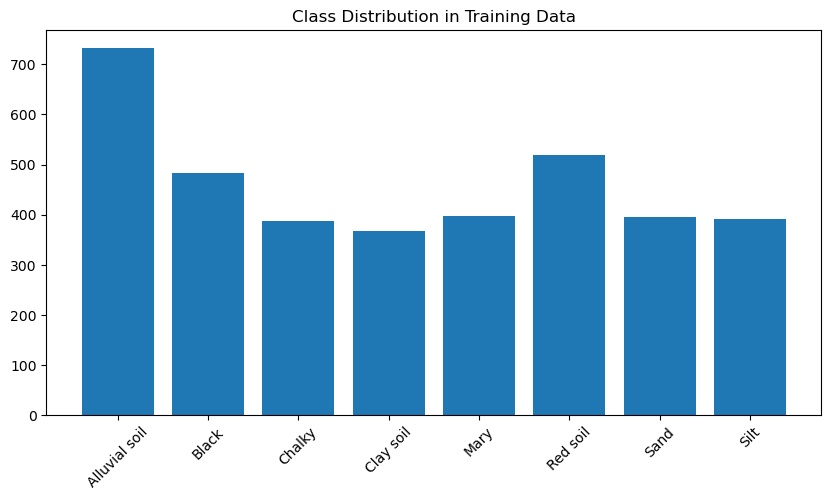

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.3314 - loss: 2.3431 - val_accuracy: 0.1421 - val_loss: 3.1288 - learning_rate: 1.0000e-04
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.4435 - loss: 1.7454 - val_accuracy: 0.2445 - val_loss: 3.2374 - learning_rate: 1.0000e-04
Epoch 3/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.4871 - loss: 1.5808 - val_accuracy: 0.3455 - val_loss: 2.8807 - learning_rate: 1.0000e-04
Epoch 4/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.5232 - loss: 1.4275 - val_accuracy: 0.3298 - val_loss: 3.6941 - learning_rate: 1.0000e-04
Epoch 5/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.5208 - loss: 1.3910 - val_accuracy: 0.3582 - val_loss: 4.9545 - learning_rate: 1.0000e-04
Epoch 6/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.5554 - loss: 1.2660 - val_accuracy: 0.3178 - val_loss: 5.5230 - learning_rate: 1.0000e-04
Epoch 7/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - acc

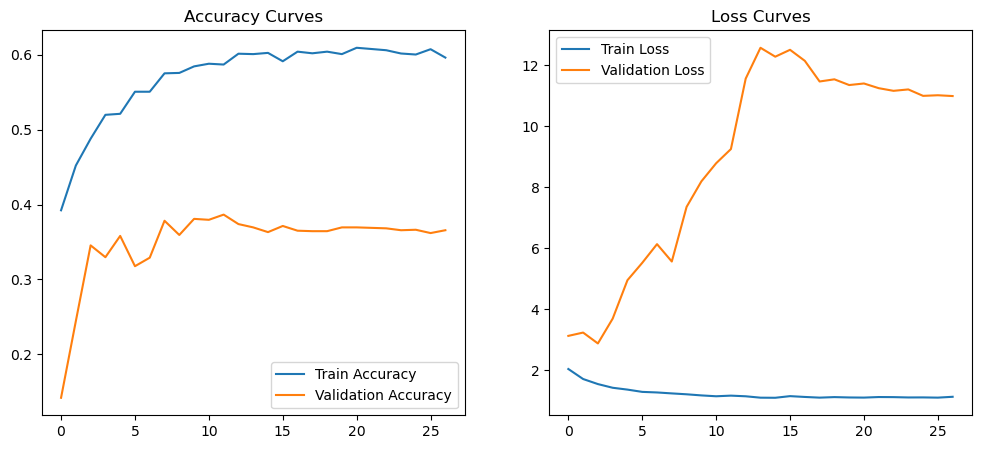

50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 335ms/step - accuracy: 0.3642 - loss: 9.3567

Test Accuracy: 38.66%
Test Loss: 9.2530
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 318ms/step

Classification Report:
               precision    recall  f1-score   support

Alluvial soil       0.16      0.12      0.14       316
        Black       0.10      0.15      0.12       209
       Chalky       0.17      0.04      0.06       166
    Clay soil       0.14      0.01      0.02       160
         Mary       0.12      0.05      0.07       172
     Red soil       0.14      0.29      0.19       222
         Sand       0.11      0.13      0.12       170
         Silt       0.12      0.17      0.14       168

     accuracy                           0.13      1583
    macro avg       0.13      0.12      0.11      1583
 weighted avg       0.13      0.13      0.11      1583



In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import os

# Set paths
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size
img_size = (150, 150)
batch_size = 32

# ==================== 1. Data Preparation ====================
# Check class imbalance
train_class_counts = {}
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        train_class_counts[class_name] = len(os.listdir(class_dir))

plt.figure(figsize=(10, 5))
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Data")
plt.show()

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

# ==================== 2. Model Architecture ====================
def build_model(use_transfer_learning=False):
    if use_transfer_learning:
        # Transfer Learning with EfficientNet
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(img_size[0], img_size[1], 3)
        )
        base_model.trainable = False
        
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            Dense(128, activation='relu'),
            Dropout(0.5),
            Dense(8, activation='softmax')
        ])
    else:
        # Improved CNN (your successful architecture)
        model = Sequential([
            Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
            BatchNormalization(),
            MaxPooling2D(2,2),
            Dropout(0.25),
            
            Conv2D(64, (3,3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D(2,2),
            Dropout(0.25),
            
            Conv2D(128, (3,3), activation='relu'),
            BatchNormalization(),
            MaxPooling2D(2,2),
            Dropout(0.25),
            
            Flatten(),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(8, activation='softmax')
        ])
    return model

# ==================== 3. Training Configuration ====================
model = build_model(use_transfer_learning=False)  # Set to True for transfer learning

optimizer = Adam(learning_rate=0.0001)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_soil_model.keras', save_best_only=True)
]

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==================== 4. Training ====================
history = model.fit(
    train_generator,
    epochs=80,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ==================== 5. Evaluation ====================
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

# Final evaluation
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")

# Classification report
from sklearn.metrics import classification_report
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
print("\nClassification Report:")
print(classification_report(test_generator.classes, y_pred_classes, 
                           target_names=list(train_class_counts.keys())))

# Experiment 2

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.3656 - loss: 1.7770 - val_accuracy: 0.1409 - val_loss: 2.1277 - learning_rate: 1.0000e-04
Epoch 2/100
  1/114 ━━━━━━━━━━━━━━━━━━━━ 3:54 2s/step - accuracy: 0.4688 - loss: 1.3848

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


114/114 ━━━━━━━━━━━━━━━━━━━━ 23s 188ms/step - accuracy: 0.4688 - loss: 1.3848 - val_accuracy: 0.1409 - val_loss: 2.1302 - learning_rate: 1.0000e-04
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.4805 - loss: 1.4097 - val_accuracy: 0.1983 - val_loss: 2.2374 - learning_rate: 1.0000e-04
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step - accuracy: 0.4688 - loss: 1.4247 - val_accuracy: 0.2054 - val_loss: 2.2453 - learning_rate: 1.0000e-04
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - accuracy: 0.5196 - loss: 1.2820 - val_accuracy: 0.3323 - val_loss: 2.0203 - learning_rate: 1.0000e-04
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 53s 411ms/step - accuracy: 0.5625 - loss: 1.1906 - val_accuracy: 0.3329 - val_loss: 2.0064 - learning_rate: 1.0000e-04
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 578s 5s/step - accuracy: 0.5329 - loss: 1.1985 - val_accuracy: 0.2876 - val_loss: 2.2679 - learning_rate: 1.0000e-04
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 53s 412ms/step - 

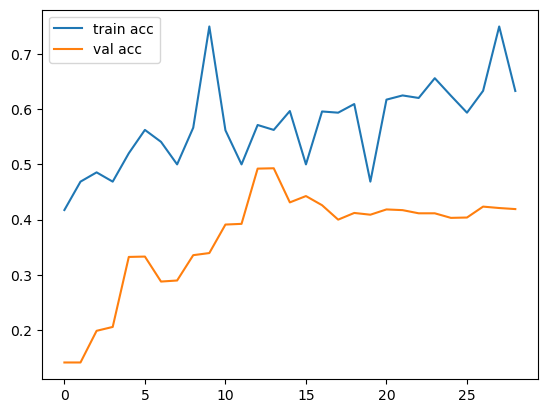

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 0.4878 - loss: 1.4053
Test Loss: 1.3869
Test Accuracy: 0.4946


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Set paths
train_dir =  r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size (you can adjust)
img_size = (150, 150)
batch_size = 32

## Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,  # Increased from 20
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,  # Increased from 0.2
    horizontal_flip=True,
    vertical_flip=True,  # New
    brightness_range=[0.8, 1.2],  # New
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build CNN model
model = Sequential([
    # Block 1
    Conv2D(32, (5,5), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),  # Additional conv layer
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),  # Additional conv layer
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Feature extraction
    GlobalAveragePooling2D(),  # Better than Flatten for reducing params
    
    # Classifier
    Dense(64, activation='relu'),  # Reduced from 128
    BatchNormalization(),
    Dropout(0.3),  # Reduced from 0.5
    Dense(8, activation='softmax')
])
optimizer = Adam(learning_rate=0.0001)  # Lower learning rate
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train with larger image size if possible
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=100,  # Increased epochs with early stopping
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    callbacks=callbacks
)

# Save the model
model.save('soil_type_cnn_model.h5')

# Plot training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Experiment 3

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.2861 - loss: 1.8505 - val_accuracy: 0.3746 - val_loss: 1.6149
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 100s 868ms/step - accuracy: 0.4685 - loss: 1.4086 - val_accuracy: 0.4833 - val_loss: 1.2560
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 102s 888ms/step - accuracy: 0.5142 - loss: 1.2494 - val_accuracy: 0.5079 - val_loss: 1.2285
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 100s 868ms/step - accuracy: 0.5661 - loss: 1.1093 - val_accuracy: 0.4687 - val_loss: 1.4829
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 100s 868ms/step - accuracy: 0.5500 - loss: 1.1279 - val_accuracy: 0.5717 - val_loss: 1.0089
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 99s 861ms/step - accuracy: 0.5793 - loss: 1.0180 - val_accuracy: 0.5199 - val_loss: 1.2919
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 96s 830ms/step - accuracy: 0.5872 - loss: 0.9977 - val_accuracy: 0.5060 - val_loss: 1.3031
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 96s 836ms/step - accuracy: 0.5977 - loss:

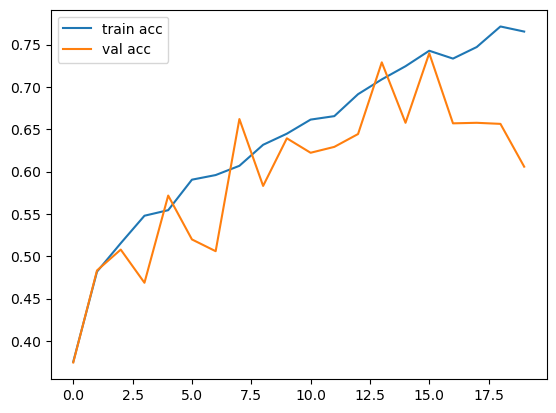

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - accuracy: 0.6003 - loss: 1.2196
Test Loss: 1.2375
Test Accuracy: 0.6058


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Set paths
train_dir =  r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size (you can adjust)
img_size = (150, 150)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 classes
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator
)

# Save the model
model.save('soil_type_cnn_model.h5')

# Plot training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Experiment 4

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 421s 4s/step - accuracy: 0.4026 - loss: 2.0115 - val_accuracy: 0.1049 - val_loss: 6.6026 - learning_rate: 0.0010
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.5082 - loss: 1.3659 - val_accuracy: 0.1674 - val_loss: 2.8800 - learning_rate: 0.0010
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.5522 - loss: 1.2136 - val_accuracy: 0.3967 - val_loss: 1.8809 - learning_rate: 0.0010
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 407s 4s/step - accuracy: 0.5843 - loss: 1.1088 - val_accuracy: 0.2697 - val_loss: 2.2527 - learning_rate: 0.0010
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 408s 4s/step - accuracy: 0.6117 - loss: 1.0683 - val_accuracy: 0.5142 - val_loss: 1.5620 - learning_rate: 0.0010
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 406s 4s/step - accuracy: 0.6230 - loss: 1.0089 - val_accuracy: 0.3872 - val_loss: 2.3442 - learning_rate: 0.0010
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.6050 - loss: 1.

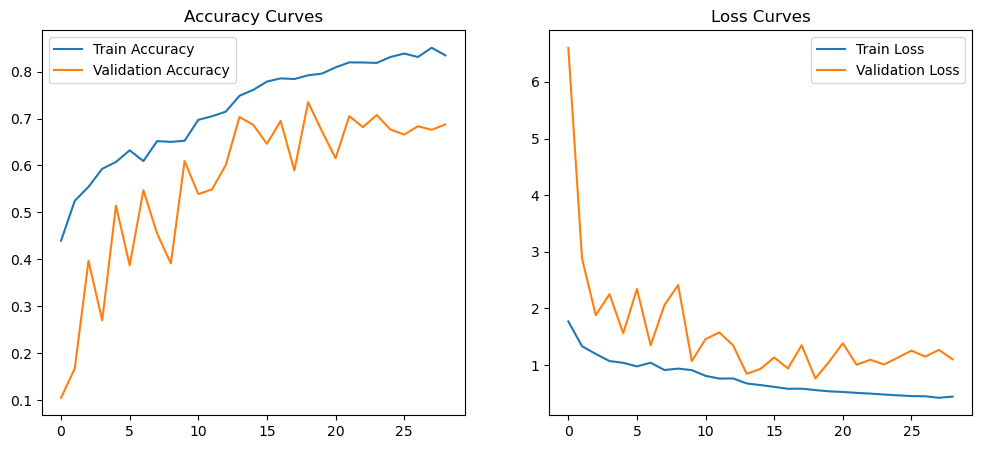

50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 555ms/step - accuracy: 0.7270 - loss: 0.7820

Test Accuracy: 73.47%
Test Loss: 0.7632


In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

# Set paths
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size
img_size = (224, 224)  # Increased from 150 to 224
batch_size = 32

# ==================== 1. Enhanced Data Augmentation ====================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# ==================== 2. Simplified But Effective Model Architecture ====================
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Feature extraction
    Flatten(),
    
    # Classifier
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

# ==================== 3. Optimized Training Configuration ====================
optimizer = Adam(learning_rate=0.001)  # Higher initial learning rate

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==================== 4. Training ====================
history = model.fit(
    train_generator,
    epochs=50,  # Reduced from 80
    validation_data=test_generator,
    callbacks=callbacks
)

# ==================== 5. Evaluation ====================
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

# Final evaluation
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")

# Experiment 5

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.
Epoch 1/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 103s 871ms/step - accuracy: 0.3290 - loss: 1.7844 - val_accuracy: 0.4157 - val_loss: 1.5650
Epoch 2/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 94s 820ms/step - accuracy: 0.4847 - loss: 1.3564 - val_accuracy: 0.4510 - val_loss: 1.3817
Epoch 3/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 96s 833ms/step - accuracy: 0.5177 - loss: 1.2287 - val_accuracy: 0.5009 - val_loss: 1.1762
Epoch 4/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 94s 812ms/step - accuracy: 0.5447 - loss: 1.1196 - val_accuracy: 0.5376 - val_loss: 1.1647
Epoch 5/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 95s 822ms/step - accuracy: 0.5869 - loss: 1.0531 - val_accuracy: 0.5995 - val_loss: 1.0927
Epoch 6/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 95s 825ms/step - accuracy: 0.6282 - loss: 0.9477 - val_accuracy: 0.5344 - val_loss: 1.2543
Epoch 7/150
115/115 ━━━━━━━━━━━━━━━━━━━━ 97s 842ms/step - accuracy: 0.6502 - loss: 0.9058 - val_accuracy: 0.5009 - val_loss

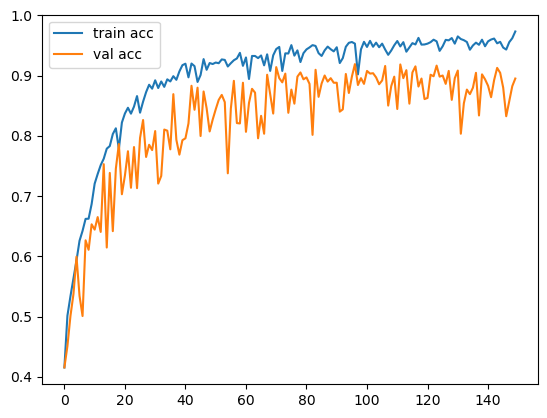

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.8893 - loss: 0.7927
Test Loss: 0.7648
Test Accuracy: 0.8951


In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Set paths
train_dir =  r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size (you can adjust)
img_size = (150, 150)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 classes
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    train_generator,
    epochs=150,
    validation_data=test_generator
)

# Save the model
model.save('soil_type_cnn_model.h5')

# Plot training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Experiment 6

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.
Epoch 1/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 104s 863ms/step - accuracy: 0.3437 - loss: 1.7737 - val_accuracy: 0.4940 - val_loss: 1.2784
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 94s 814ms/step - accuracy: 0.5092 - loss: 1.2688 - val_accuracy: 0.4075 - val_loss: 1.5481
Epoch 3/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 96s 831ms/step - accuracy: 0.5451 - loss: 1.1851 - val_accuracy: 0.5477 - val_loss: 1.1286
Epoch 4/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 810ms/step - accuracy: 0.5658 - loss: 1.0576 - val_accuracy: 0.5212 - val_loss: 1.1691
Epoch 5/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 809ms/step - accuracy: 0.5665 - loss: 1.0431 - val_accuracy: 0.5420 - val_loss: 1.1651
Epoch 6/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 94s 813ms/step - accuracy: 0.5795 - loss: 1.0162 - val_accuracy: 0.6349 - val_loss: 0.9505
Epoch 7/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 93s 805ms/step - accuracy: 0.6208 - loss: 0.9113 - val_accuracy: 0.5281 - val_loss: 1.174

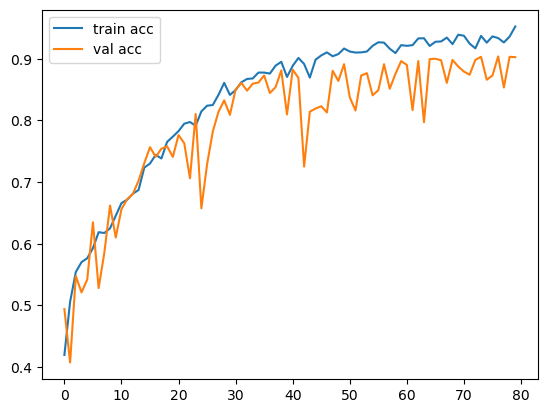

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 261ms/step - accuracy: 0.9000 - loss: 0.6574
Test Loss: 0.5712
Test Accuracy: 0.9027


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Set paths
train_dir =  r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size (you can adjust)
img_size = (150, 150)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 classes
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    train_generator,
    epochs=80,
    validation_data=test_generator
)

# Save the model
model.save('soil_type_cnn_model.h5')

# Plot training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# unwanted codes

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

# Set paths
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Increased image size for better feature extraction
img_size = (224, 224)
batch_size = 32

# Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build Advanced CNN Model
model = Sequential([
    # First Conv Block
    Conv2D(64, (5,5), activation='relu', input_shape=(img_size[0], img_size[1], 3), padding='same'),
    BatchNormalization(),
    Conv2D(64, (5,5), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Second Conv Block
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Third Conv Block
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Fourth Conv Block
    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Dense Layers
    Flatten(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

# Custom Optimizer with lower learning rate
optimizer = Adam(learning_rate=0.0001)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7),
    ModelCheckpoint('best_soil_model.h5', monitor='val_accuracy', save_best_only=True)
]

# Compile Model
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy', 
                      tf.keras.metrics.Precision(name='precision'),
                      tf.keras.metrics.Recall(name='recall')])

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=100,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    callbacks=callbacks,
    verbose=1
)

# Save Final Model
model.save('final_soil_model.h5')

# Plot Training History
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate Model
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Test Time Augmentation (Optional for final prediction)
def predict_with_tta(model, generator, steps=5):
    predictions = []
    for i in range(steps):
        preds = model.predict(generator, verbose=0)
        predictions.append(preds)
    return np.mean(predictions, axis=0)

tta_predictions = predict_with_tta(model, test_generator, steps=5)

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.
Epoch 1/100
 35/114 ━━━━━━━━━━━━━━━━━━━━ 1:45:14 80s/step - accuracy: 0.3170 - loss: 2.5835 - precision: 0.3744 - recall: 0.2277

KeyboardInterrupt: 

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Enable GPU optimizations
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.optimizer.set_jit(True)  # Enable XLA compilation
    except RuntimeError as e:
        print(e)

# Set paths
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Image size and batch size
img_size = (150, 150)
batch_size = 64  # Increased batch size for better GPU utilization

# Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]  # Added brightness variation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Optimized CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),  # Added batch norm
    MaxPooling2D(2,2),
    Dropout(0.25),  # Reduced dropout

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu'),  # Added extra layer
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

# Custom optimizer with learning rate scheduling
optimizer = Adam(learning_rate=0.0001)

# Callbacks for early stopping and learning rate adjustment
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(
    train_generator,
    epochs=50,  # Reduced epochs with early stopping
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

# Save the model
model.save('optimized_soil_model.h5')

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate model
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.
Epoch 1/50
23/58 ━━━━━━━━━━━━━━━━━━━━ 1:41 3s/step - accuracy: 0.2775 - loss: 2.7869

KeyboardInterrupt: 

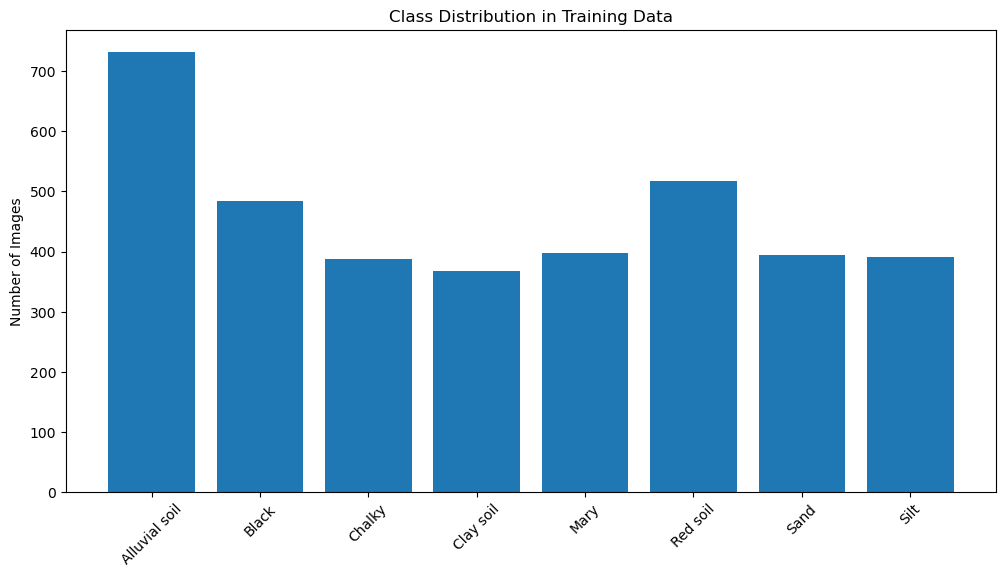

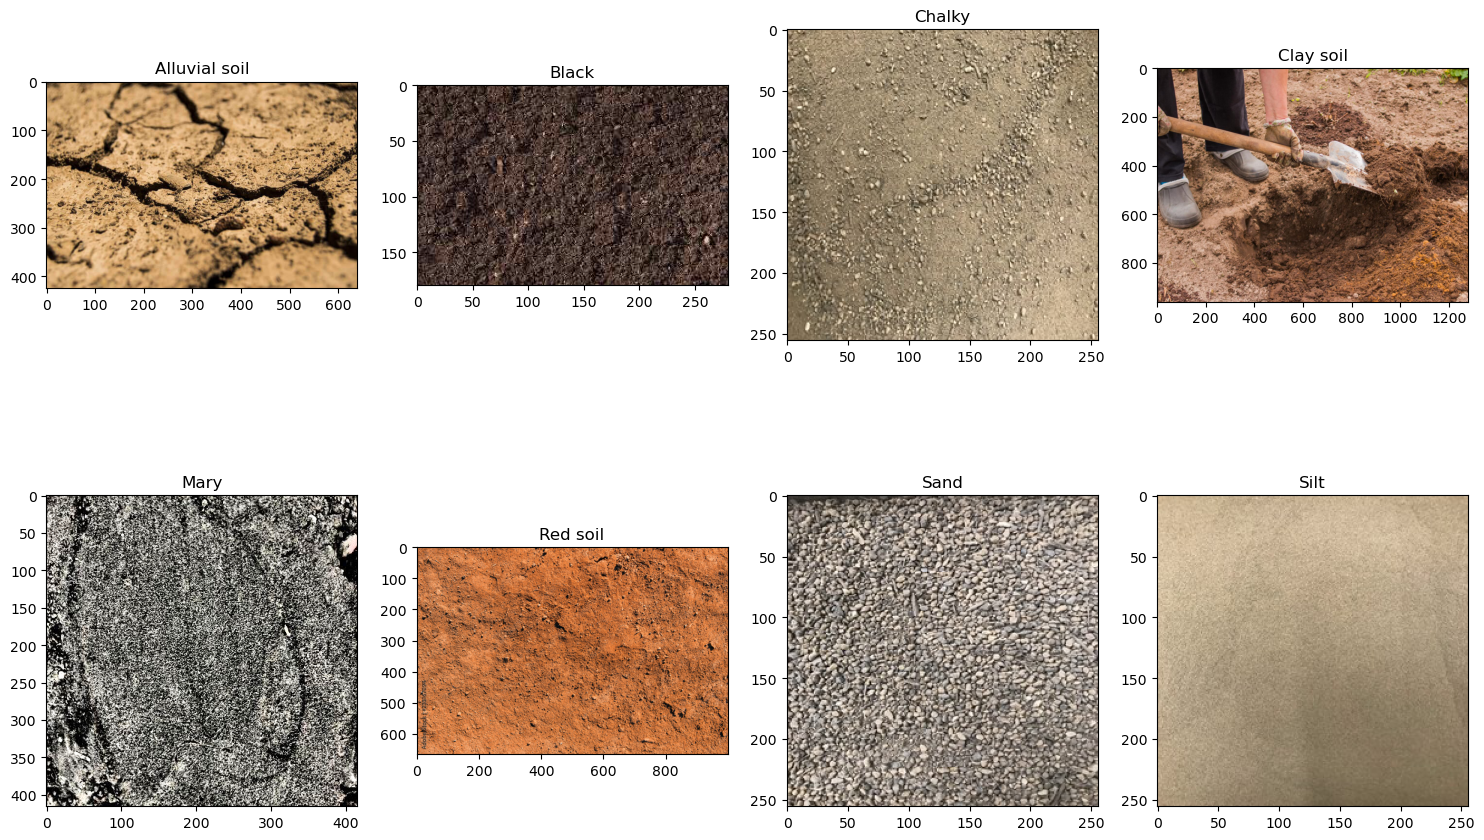

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 440s 3s/step - accuracy: 0.2271 - loss: 6.0697 - val_accuracy: 0.1074 - val_loss: 4.6227 - learning_rate: 3.0000e-04
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.3237 - loss: 4.1175 - val_accuracy: 0.1901 - val_loss: 3.0133 - learning_rate: 3.0000e-04
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.3546 - loss: 2.6582 - val_accuracy: 0.2015 - val_loss: 1.9585 - learning_rate: 3.0000e-04
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.3894 - loss: 1.7333 - val_accuracy: 0.4075 - val_loss: 1.3134 - learning_rate: 3.0000e-04
Epoch 5/100
  2/115 ━━━━━━━━━━━━━━━━━━━━ 5:04 3s/step - accuracy: 0.3828 - loss: 1.3899

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==================== 1. Data Analysis ====================
# Set paths
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

# Get class names and counts
class_names = sorted(os.listdir(train_dir))
class_counts = [len(os.listdir(os.path.join(train_dir, name))) for name in class_names]

# Plot class distribution
plt.figure(figsize=(12,6))
plt.bar(class_names, class_counts)
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Images")
plt.show()

# Display sample images
plt.figure(figsize=(15,10))
for i, class_name in enumerate(class_names[:8]):
    img_path = os.path.join(train_dir, class_name, os.listdir(os.path.join(train_dir, class_name))[0])
    img = Image.open(img_path)
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(class_name)
plt.tight_layout()
plt.show()

# ==================== 2. Enhanced Data Pipeline ====================
# ==================== 2. Enhanced Data Pipeline ====================
img_size = (224, 224)
batch_size = 32

# Create base data generator with comprehensive augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

# Create single generator with balanced class weights
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Standard generator for validation
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)
# ==================== 3. Focal Loss Implementation ====================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.pow(1 - y_pred, gamma) * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fn

# ==================== 4. Optimized Model Architecture ====================
# ==================== 4. Optimized Model Architecture ====================
def build_soil_model():
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size[0], img_size[1], 3)
    )
    
    # Fine-tuning strategy
    for layer in base_model.layers[:100]:
        layer.trainable = False
    for layer in base_model.layers[100:]:
        layer.trainable = True
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(8, activation='softmax')
    ])
    
    return model

model = build_soil_model()
# ==================== 5. Training Configuration ====================
# Precise class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

optimizer = Adam(learning_rate=3e-4, clipnorm=1.0)  # Gradient clipping

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    ModelCheckpoint('best_soil_model.keras', monitor='val_accuracy', save_best_only=True)
]

model.compile(
    optimizer=optimizer,
    loss=focal_loss(),
    metrics=['accuracy']
)

# ==================== 6. Training ====================
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ==================== 7. Evaluation ====================
# Plot training history
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

# Generate predictions
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(test_generator.classes, y_pred_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Save final model
model.save('soil_classifier_final.keras')

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

# -------------------------------
# 1) Paths & Settings
# -------------------------------
train_dir = r'C:\Users\ASUS\Soil_Data_V3\Trains'
test_dir = r'C:\Users\ASUS\Soil_Data_V3\Tests'

img_size = (224, 224)  # increased image size
batch_size = 64        # increased batch size
epochs = 100

# -------------------------------
# 2) Data Augmentation
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,       # added vertical flip
    brightness_range=[0.8,1.2],  # brightness augmentation
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# -------------------------------
# 3) Build CNN Model
# -------------------------------
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),  # added batch normalization
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),  # added another Conv layer
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),  # increased dense size
    Dropout(0.5),
    Dense(8, activation='softmax')
])

# -------------------------------
# 4) Compile Model
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # slightly lower LR for stable learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 5) Callbacks
# -------------------------------
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
)

# -------------------------------
# 6) Train Model
# -------------------------------
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[reduce_lr, early_stop]
)

# -------------------------------
# 7) Save Model
# -------------------------------
model.save('soil_type_cnn_improved.keras')  # use recommended keras format

# -------------------------------
# 8) Plot Accuracy & Loss
# -------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

# -------------------------------
# 9) Evaluate
# -------------------------------
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 3665 images belonging to 8 classes.
Found 1583 images belonging to 8 classes.


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10/58 ━━━━━━━━━━━━━━━━━━━━ 5:43 7s/step - accuracy: 0.2589 - loss: 4.6525

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted Soil Type: Black soil
Confidence: 0.9931


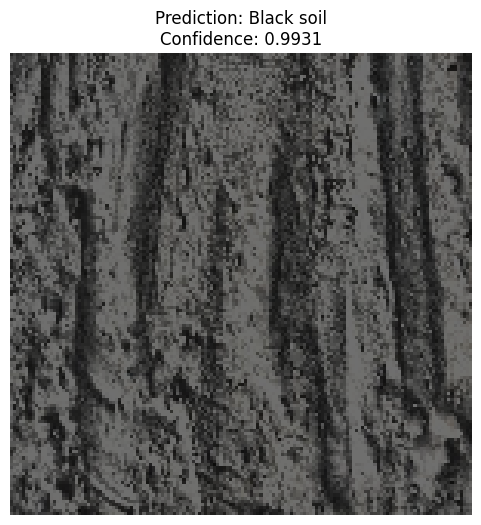

In [30]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('soil_type_cnn_model.h5')

# Define class labels IN THE SAME ORDER AS ALPHABETICALLY SORTED FOLDER NAMES
class_labels = [
    'Alluvial soil',
    'Black soil',
    'chalky soil',
    'clay soil',
    'mary',
    'red soil',
    'sand',
    'silt'
]

def predict_soil_type(img_path):
    # Load and preprocess image exactly as during training
    img = image.load_img(img_path, target_size=(150, 150))  # Must match img_size
    img_array = image.img_to_array(img)                     # Shape: (150, 150, 3)
    img_array = np.expand_dims(img_array, axis=0)           # Add batch dimension: (1, 150, 150, 3)
    img_array /= 255.0                                      # Same rescaling as in ImageDataGenerator

    # Predict
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index]
    predicted_class = class_labels[predicted_index]

    # Output result
    print(f"Predicted Soil Type: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")

    # Display image with prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.4f}", fontsize=12)
    plt.axis('off')
    plt.show()

# 🔁 Replace this path with your actual test image
predict_soil_type(r'C:\Users\ASUS\Soil_Data_V3\Trains\Silt\augmented_144.png')

In [31]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available:  0
[]


In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [33]:
import tensorflow as tf
print("TF Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

TF Version: 2.20.0
GPU Available: []
Built with CUDA: False


In [34]:
import tensorflow as tf
print(tf.__version__)
print(tf.__file__)

2.20.0
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\tensorflow\__init__.py
